In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_csv(r'/Users/anirudhiyer/Desktop/Stress Prediction/Minor-Project/Datasets/Final_processed.csv')

In [4]:
df.head()

,Unnamed: 0,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,2,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,3,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,4,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,1
4,5,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0


In [5]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [6]:
df.head()

,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,final_label
0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,3.0,...,0,0,0,1.0,0,1.0,1,0,1,0
1,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0
2,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,0.0,...,0,0,0,1.0,0,1.0,1,0,1,0
3,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,1.0,...,0,0,0,1.0,0,1.0,1,0,1,1
4,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,...,0,0,0,1.0,0,1.0,1,0,1,0


### K-Means Clustering

In [7]:
labels=df['final_label']
X=df.drop(columns=['final_label'])

In [8]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [9]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

In [12]:
def evaluate_kmeans(k, X_scaled, true_labels):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, clusters)
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil_score, ari, nmi, clusters


results = {}

for k in [2, 3]:
    sil, ari, nmi, clusters = evaluate_kmeans(k, X_scaled, labels)
    
    results[k] = {
        "Silhouette Score": sil,
        "ARI": ari,
        "NMI": nmi
    }
    
    print(f"\nResults for K = {k}")
    print(f"Silhouette Score : {sil}")
    print(f"Adjusted Rand Index (ARI): {ari}")
    print(f"Normalized Mutual Info (NMI): {nmi}")



Results for K = 2
Silhouette Score : 0.15988487991897823
Adjusted Rand Index (ARI): 0.4911324820956801
Normalized Mutual Info (NMI): 0.4581166043459329

Results for K = 3
Silhouette Score : 0.11688040661940971
Adjusted Rand Index (ARI): 0.5224415208491576
Normalized Mutual Info (NMI): 0.43812627425601447


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

### Conclusions:
1. The moderate ARI (~0.52) shows partial agreement, meaning clustering captures meaningful patterns but not exactly the scoring system — highlighting limitations of rule-based categorization.

2. K-Means clustering with K=2 produced better-separated clusters as indicated by higher silhouette scores, whereas K=3 showed slightly better alignment with predefined labels. This suggests that while traditional scoring divides individuals into three categories, the underlying data structure may represent fewer, more cohesive groups, indicating overlap in intermediate psychological states.

In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

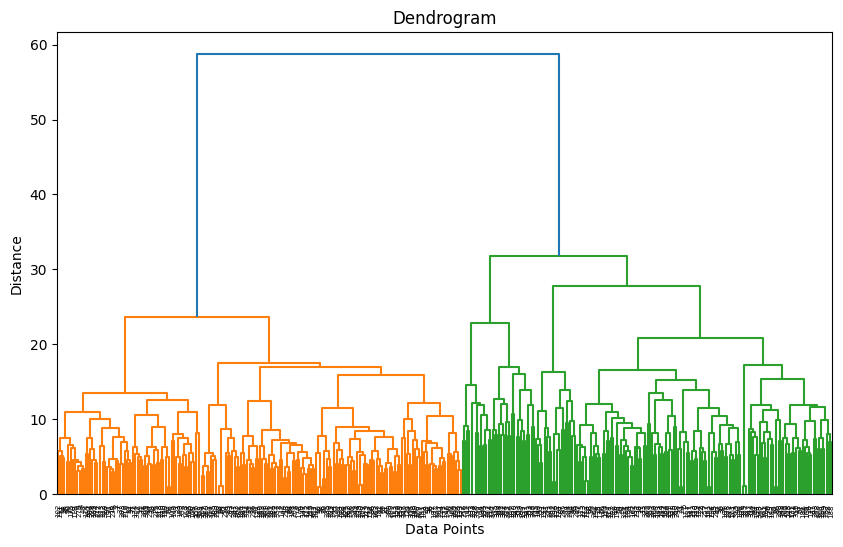

In [14]:
plt.figure(figsize=(10, 6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [15]:
def evaluate_hierarchical(k, X_scaled, true_labels):
    
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    clusters = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, clusters)
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil, ari, nmi, clusters

In [16]:
for k in [2, 3]:
    sil, ari, nmi, clusters = evaluate_hierarchical(k, X_scaled, labels)
    
    print(f"\nHierarchical Results for K = {k}")
    print(f"Silhouette Score : {sil}")
    print(f"Adjusted Rand Index (ARI): {ari}")
    print(f"Normalized Mutual Info (NMI): {nmi}")


Hierarchical Results for K = 2
Silhouette Score : 0.1371406698498609
Adjusted Rand Index (ARI): 0.40917218247365483
Normalized Mutual Info (NMI): 0.3733766135599923

Hierarchical Results for K = 3
Silhouette Score : 0.12437557359514656
Adjusted Rand Index (ARI): 0.3888641872797644
Normalized Mutual Info (NMI): 0.33280808643040527


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

### Conclusions:

1. Hierarchical clustering revealed two dominant groups in the dataset, suggesting that individuals tend to cluster into broader categories of psychological states rather than distinct three-level classifications.

In [17]:
def evaluate_kmeans(k, X_scaled, true_labels):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_          # ← Add this
    sil_score = silhouette_score(X_scaled, clusters)
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil_score, ari, nmi, clusters, inertia   # ← Return inertia too


# Expand your k range for a meaningful elbow curve
k_range = range(2, 11)
results = {}
inertias = []   # ← Track inertia across k values

for k in k_range:
    sil, ari, nmi, clusters, inertia = evaluate_kmeans(k, X_scaled, labels)
    
    inertias.append(inertia)          # ← Collect for elbow plot
    results[k] = {
        "Silhouette Score": sil,
        "ARI": ari,
        "NMI": nmi,
        "Inertia": inertia
    }
    
    print(f"\nResults for K = {k}")
    print(f"Inertia              : {inertia:.2f}")
    print(f"Silhouette Score     : {sil:.4f}")
    print(f"Adjusted Rand Index  : {ari:.4f}")
    print(f"Normalized Mutual Info: {nmi:.4f}")





Results for K = 2
Inertia              : 11066.02
Silhouette Score     : 0.1599
Adjusted Rand Index  : 0.4911
Normalized Mutual Info: 0.4581

Results for K = 3
Inertia              : 10398.46
Silhouette Score     : 0.1169
Adjusted Rand Index  : 0.5224
Normalized Mutual Info: 0.4381

Results for K = 4
Inertia              : 10052.79
Silhouette Score     : 0.1159
Adjusted Rand Index  : 0.5047
Normalized Mutual Info: 0.4080

Results for K = 5
Inertia              : 9722.16
Silhouette Score     : 0.0508
Adjusted Rand Index  : 0.2594
Normalized Mutual Info: 0.3366

Results for K = 6
Inertia              : 9553.55
Silhouette Score     : 0.0435
Adjusted Rand Index  : 0.2683
Normalized Mutual Info: 0.3697

Results for K = 7
Inertia              : 9257.63
Silhouette Score     : 0.0460
Adjusted Rand Index  : 0.2551
Normalized Mutual Info: 0.3425

Results for K = 8
Inertia              : 9113.24
Silhouette Score     : 0.0317
Adjusted Rand Index  : 0.1874
Normalized Mutual Info: 0.3392

Results f

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

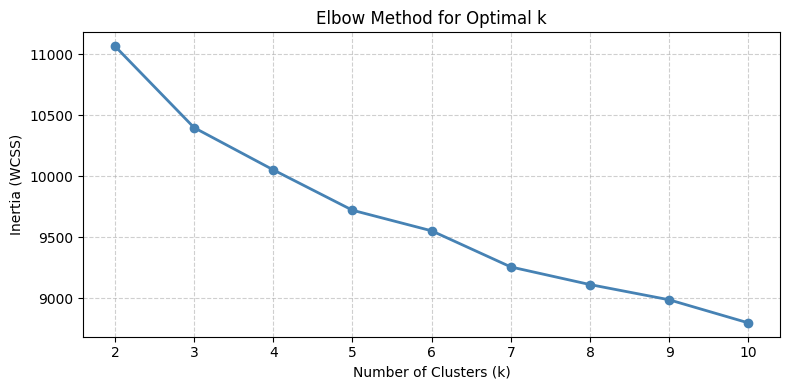

In [18]:
# --- Elbow Plot ---
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

labels = df['final_label']
X = df.drop(columns=['final_label'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def evaluate_kmeans(k, X_scaled, true_labels):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, clusters) if len(set(clusters)) > 1 else -1
    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    
    return sil_score, ari, nmi, kmeans.inertia_, clusters

results = {}

for k in range(2, 7):
    sil, ari, nmi, inertia, clusters = evaluate_kmeans(k, X_scaled, labels)
    
    results[k] = {
        "Silhouette Score": sil,
        "ARI": ari,
        "NMI": nmi,
        "Inertia": inertia,
        "Clusters": clusters
    }
    
    print(f"\nResults for K = {k}")
    print(f"Silhouette Score : {sil}")
    print(f"Adjusted Rand Index (ARI): {ari}")
    print(f"Normalized Mutual Info (NMI): {nmi}")
    print(f"Inertia: {inertia}")


Results for K = 2
Silhouette Score : 0.15988487991897823
Adjusted Rand Index (ARI): 0.4911324820956801
Normalized Mutual Info (NMI): 0.4581166043459329
Inertia: 11066.020539103796

Results for K = 3
Silhouette Score : 0.11688040661940971
Adjusted Rand Index (ARI): 0.5224415208491576
Normalized Mutual Info (NMI): 0.43812627425601447
Inertia: 10398.457555629564

Results for K = 4
Silhouette Score : 0.11588716673583233
Adjusted Rand Index (ARI): 0.5046847338945196
Normalized Mutual Info (NMI): 0.40801344286706465
Inertia: 10052.793339671707

Results for K = 5
Silhouette Score : 0.05078955693932995
Adjusted Rand Index (ARI): 0.2593578022979864
Normalized Mutual Info (NMI): 0.33655630630314004
Inertia: 9722.160429782249

Results for K = 6
Silhouette Score : 0.04350756386933463
Adjusted Rand Index (ARI): 0.268328138705178
Normalized Mutual Info (NMI): 0.3697307307638014
Inertia: 9553.545272532108


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

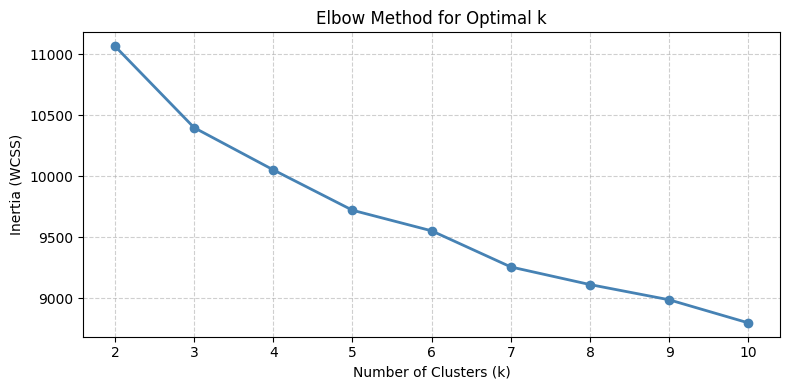

In [20]:
# --- Elbow Plot ---
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Explained Variance Ratio: [0.21149858 0.07560473]


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Predicti

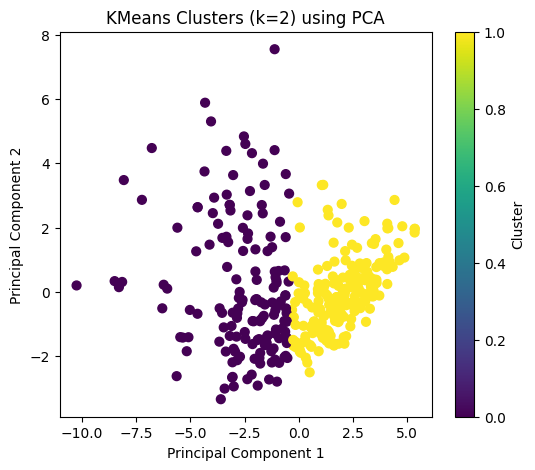

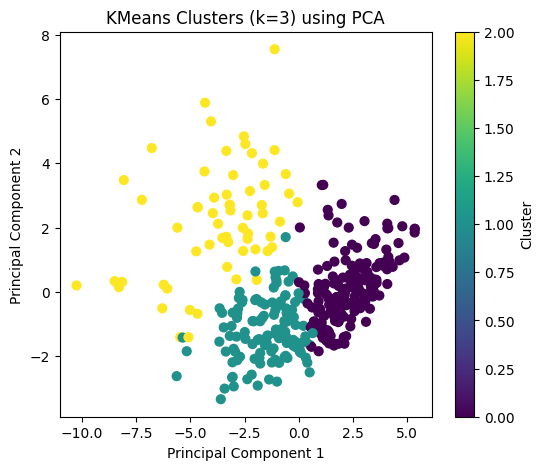

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Plot function
def plot_clusters(X_pca, clusters, k):
    plt.figure(figsize=(6,5))
    
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=clusters,
        cmap='viridis',
        s=40
    )
    
    plt.title(f"KMeans Clusters (k={k}) using PCA")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(label="Cluster")
    
    plt.show()

# Plot for k = 2 and k = 3
for k in [2, 3]:
    clusters = results[k]["Clusters"]
    plot_clusters(X_pca, clusters, k)

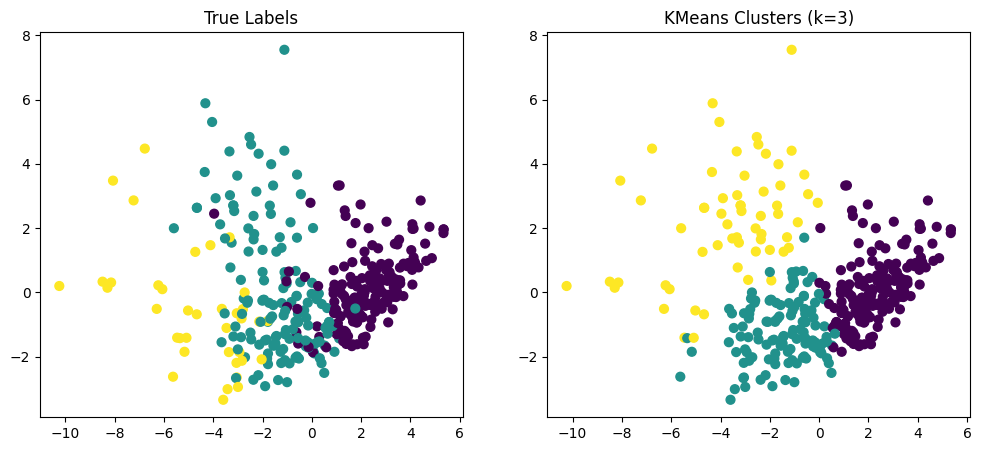

In [22]:
plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=40)
plt.title("True Labels")

# Predicted clusters (k=3)
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=results[3]["Clusters"], cmap='viridis', s=40)
plt.title("KMeans Clusters (k=3)")

plt.show()

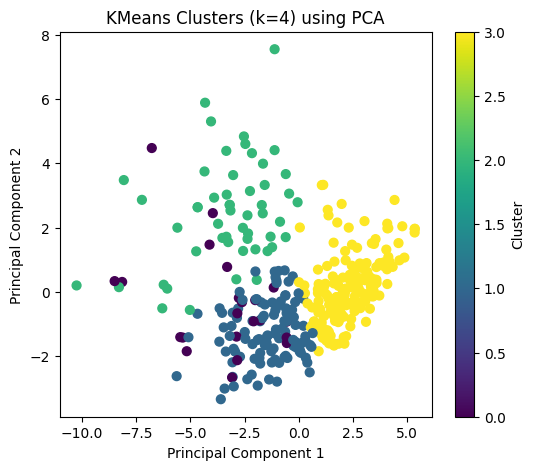

In [23]:
import matplotlib.pyplot as plt

# Ensure k=4 was computed
k = 4
clusters = results[k]["Clusters"]

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=40
)

plt.title("KMeans Clusters (k=4) using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

### T-SNE Visualisation

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/li

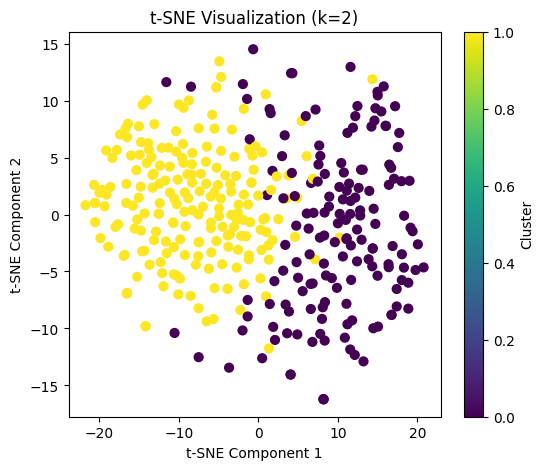

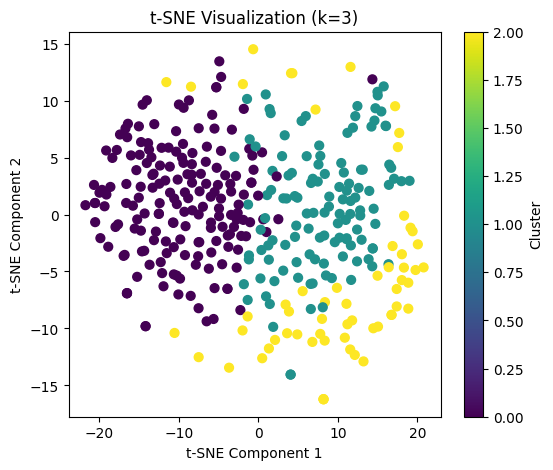

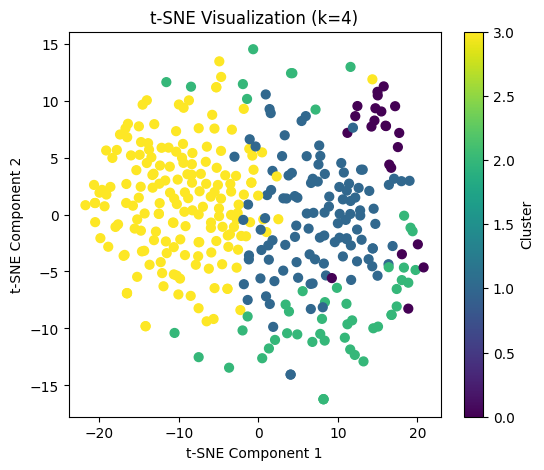

In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE (fixed)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot function
def plot_tsne(X_tsne, clusters, k):
    plt.figure(figsize=(6,5))
    
    plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=clusters,
        cmap='viridis',
        s=40
    )
    
    plt.title(f"t-SNE Visualization (k={k})")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.colorbar(label="Cluster")
    
    plt.show()

# Plot for k = 2, 3, 4
for k in [2, 3, 4]:
    clusters = results[k]["Clusters"]
    plot_tsne(X_tsne, clusters, k)